**<h1 align="center">Results Analysis</h1>**

<a class="anchor" id="chapter1"></a>

# 1. Imports & Setup

</a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import sys
import json

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
BASE = "/content/drive/MyDrive/NOVA IMS/Year 2/Thesis"
if BASE not in sys.path:
    sys.path.insert(0, BASE)

from thesis_utility import metrics_dict_to_series

In [ ]:
RESULTS_PATH = f"{BASE}/Results/"

<a class="anchor" id="chapter2"></a>

# 2. Load Results

</a>

In [ ]:
# Baseline for off the shelf and tuned models
with open(RESULTS_PATH + "SBERT_off_shelf_val_metrics_01202026_1923.json", "r") as f:
    off_shelf_val = json.load(f)

with open(RESULTS_PATH + "SBERT_off_shelf_test_metrics_01202026_1923.json", "r") as f:
    off_shelf_test = json.load(f)

with open(RESULTS_PATH + "SBERT_tuned_val_metrics_01202026_1923.json", "r") as f:
    tuned_val = json.load(f)

with open(RESULTS_PATH + "SBERT_tuned_test_metrics_01202026_1923.json", "r") as f:
    tuned_test = json.load(f)

In [ ]:
# ESCO features for off the shelf and tuned models
with open(RESULTS_PATH + "ESCO_fixedhybrid_offshelf_val_01222026_1755.json", "r") as f:
    esco_off_shelf_val = json.load(f)

with open(RESULTS_PATH + "ESCO_fixedhybrid_offshelf_test_01222026_1755.json", "r") as f:
    esco_off_shelf_test = json.load(f)

with open(RESULTS_PATH + "ESCO_fixedhybrid_tuned_val_01222026_1755.json", "r") as f:
    esco_tuned_val = json.load(f)

with open(RESULTS_PATH + "ESCO_fixedhybrid_tuned_test_01222026_1755.json", "r") as f:
    esco_tuned_test = json.load(f)

In [ ]:
# Tuned Results
with open(RESULTS_PATH + "ESCO_tunedhybrid_offshelf_val_01222026_1755.json", "r") as f:
    tuned_esco_offshelf_val = json.load(f)

with open(RESULTS_PATH + "ESCO_tunedhybrid_offshelf_test_01222026_1755.json", "r") as f:
    tuned_esco_offshelf_test = json.load(f)

In [ ]:
tuning_val_results = pd.read_csv(f"{RESULTS_PATH}/ESCO_tuning_offshelf_VAL_01222026_1755.csv")

In [ ]:
# Rerankers
with open(RESULTS_PATH + "ESCO_logreg_reranker_offshelf_val_01222026_1755.json", "r") as f:
    esco_logreg_offshelf_val = json.load(f)

with open(RESULTS_PATH + "ESCO_logreg_reranker_offshelf_test_01222026_1755.json", "r") as f:
    esco_logreg_offshelf_test = json.load(f)

with open(RESULTS_PATH + "ESCO_xgb_reranker_offshelf_val_02012026_1427.json", "r") as f:
    esco_xgb_offshelf_val = json.load(f)

with open(RESULTS_PATH + "ESCO_xgb_reranker_offshelf_test_02012026_1427.json", "r") as f:
    esco_xgb_offshelf_test = json.load(f)

<a class="anchor" id="chapter3"></a>

# 3. Comparison Tables
</a>

In [ ]:
METRICS_TO_KEEP = ["recall@1", "recall@5", "recall@10", "recall@20", "mrr@10", "ndcg@10"]
BASELINE_COL = "SBERT off shelf"

In [ ]:
val_table = pd.DataFrame({
    "SBERT off shelf": metrics_dict_to_series(off_shelf_val),
    "SBERT tuned": metrics_dict_to_series(tuned_val),
    "SBERT off shelf + ESCO": metrics_dict_to_series(esco_off_shelf_val),
    "SBERT tuned + ESCO": metrics_dict_to_series(esco_tuned_val),
    "SBERT off shelf + ESCO tuning": metrics_dict_to_series(tuned_esco_offshelf_val),
    "Reranker (logreg)": metrics_dict_to_series(esco_logreg_offshelf_val),
    "Reranker (xgb)": metrics_dict_to_series(esco_xgb_offshelf_val),
})
val_table = val_table.loc[METRICS_TO_KEEP]
val_table

,SBERT off shelf,SBERT tuned,SBERT off shelf + ESCO,SBERT tuned + ESCO,SBERT off shelf + ESCO tuning,Reranker (logreg),Reranker (xgb)
recall@1,0.023359,0.020861,0.030750,0.029280,0.029190,0.031168,0.052594
recall@5,0.075230,0.071636,0.100555,0.095379,0.106883,0.109426,0.140300
recall@10,0.109776,0.108307,0.133508,0.130977,0.139984,0.143057,0.175355
recall@20,0.155579,0.156743,0.173027,0.175061,0.176451,0.179898,0.207687
mrr@10,0.045793,0.043075,0.060350,0.057675,0.062675,0.064334,0.089117
ndcg@10,0.060749,0.058274,0.077678,0.074964,0.081096,0.083063,0.109671


In [ ]:
test_table = pd.DataFrame({
    "SBERT off shelf": metrics_dict_to_series(off_shelf_test),
    "SBERT tuned": metrics_dict_to_series(tuned_test),
    "SBERT off shelf + ESCO": metrics_dict_to_series(esco_off_shelf_test),
    "SBERT tuned + ESCO": metrics_dict_to_series(esco_tuned_test),
    "SBERT off shelf + ESCO tuning": metrics_dict_to_series(tuned_esco_offshelf_test),
    "Reranker (logreg)": metrics_dict_to_series(esco_logreg_offshelf_test),
    "Reranker (xgb)": metrics_dict_to_series(esco_xgb_offshelf_test),
})

test_table = test_table.loc[METRICS_TO_KEEP]
test_table

,SBERT off shelf,SBERT tuned,SBERT off shelf + ESCO,SBERT tuned + ESCO,SBERT off shelf + ESCO tuning,Reranker (logreg),Reranker (xgb)
recall@1,0.023589,0.021220,0.030741,0.030019,0.029173,0.031204,0.049795
recall@5,0.075516,0.072459,0.100064,0.097086,0.107126,0.108119,0.136322
recall@10,0.108514,0.109574,0.132486,0.131539,0.139086,0.142166,0.171779
recall@20,0.155083,0.157959,0.171497,0.175592,0.174870,0.178785,0.203987
mrr@10,0.045936,0.043642,0.060181,0.058531,0.062306,0.063762,0.085541
ndcg@10,0.060595,0.059005,0.077317,0.075774,0.080599,0.082393,0.106054


In [ ]:
def style_results_table(df: pd.DataFrame, baseline_col: str = BASELINE_COL):
    def fmt_cell(val, is_best=False, is_second=False, is_baseline=False):
        styles = []
        if is_baseline:
            styles.append("font-weight: bold")
        if is_best:
            styles.append("background-color: #fff3cd")
        return "; ".join(styles)

    def apply_row(row: pd.Series):
        # rank values in this metric row (higher is better for these metrics)
        vals = row.astype(float)
        order = vals.sort_values(ascending=False)

        best_col = order.index[0]
        second_col = order.index[1] if len(order) > 1 else None

        out = []
        for col in row.index:
            out.append(fmt_cell(
                row[col],
                is_best=(col == best_col),
                is_baseline=(col == baseline_col)
            ))
        return out

    return (df.style
              .apply(apply_row, axis=1)
              .format("{:.4f}")  # adjust decimals if you want
           )

In [ ]:
style_results_table(test_table, baseline_col=BASELINE_COL)

,SBERT off shelf,SBERT tuned,SBERT off shelf + ESCO,SBERT tuned + ESCO,SBERT off shelf + ESCO tuning,Reranker (logreg),Reranker (xgb)
recall@10,0.1085,0.1096,0.1325,0.1315,0.1391,0.1422,0.1718
mrr@10,0.0459,0.0436,0.0602,0.0585,0.0623,0.0638,0.0855
map@10,0.0459,0.0436,0.0602,0.0585,0.0623,0.0638,0.0855
ndcg@10,0.0606,0.0590,0.0773,0.0758,0.0806,0.0824,0.1061


<a class="anchor" id="chapter4"></a>

# 4. Checks
</a>

In [ ]:
def check_monotonicity(table, metric_prefix="recall"):
    problems = []
    for model in table.columns:
        values = []
        Ks = []
        for idx in table.index:
            if idx.startswith(metric_prefix):
                K = int(idx.split("@")[1])
                Ks.append(K)
                values.append(table.loc[idx, model])

        # sort by K
        Ks, values = zip(*sorted(zip(Ks, values)))

        for i in range(1, len(values)):
            if values[i] + 1e-9 < values[i-1]:
                problems.append((model, metric_prefix, Ks[i-1], Ks[i], values[i-1], values[i]))

    return problems

In [ ]:
print("Validation recall monotonicity issues:")
print(check_monotonicity(val_table, "recall"))

print("\nTest recall monotonicity issues:")
print(check_monotonicity(test_table, "recall"))

Validation recall monotonicity issues:
[]

Test recall monotonicity issues:
[]


<a class="anchor" id="chapter5"></a>

# 5. Summary Comparison
</a>

In [ ]:
def rank_models(table, metric):
    return table.loc[metric].rank(ascending=False)

In [ ]:
rank_models(val_table, "recall@10"), rank_models(test_table, "recall@10")


(SBERT off shelf                  6.0
 SBERT tuned                      7.0
 SBERT off shelf + ESCO           4.0
 SBERT tuned + ESCO               5.0
 SBERT off shelf + ESCO tuning    3.0
 Reranker (logreg)                2.0
 Reranker (xgb)                   1.0
 Name: recall@10, dtype: float64,
 SBERT off shelf                  7.0
 SBERT tuned                      6.0
 SBERT off shelf + ESCO           4.0
 SBERT tuned + ESCO               5.0
 SBERT off shelf + ESCO tuning    3.0
 Reranker (logreg)                2.0
 Reranker (xgb)                   1.0
 Name: recall@10, dtype: float64)

In [ ]:
def delta(table, model_a, model_b, metric):
    return table.loc[metric, model_b] - table.loc[metric, model_a]

In [ ]:
for metric in ["recall@5", "recall@10", "ndcg@10", "mrr@10"]:
    print(
        metric,
        "VAL Δ:",
        delta(val_table, "SBERT off shelf", "SBERT off shelf + ESCO tuning", metric),
        "TEST Δ:",
        delta(test_table, "SBERT off shelf", "SBERT off shelf + ESCO tuning", metric),
    )

recall@5 VAL Δ: 0.031653651866333676 TEST Δ: 0.03160994099928928
recall@10 VAL Δ: 0.030207144390828236 TEST Δ: 0.030572069988605982
ndcg@10 VAL Δ: 0.020346751678584074 TEST Δ: 0.020004455115158325
mrr@10 VAL Δ: 0.016882306418858732 TEST Δ: 0.01636979186531847


In [ ]:
def percent_gain(base, new):
    return 100.0 * (new - base) / max(base, 1e-9)

metric = "recall@10"

print(
    "ESCO gain over SBERT off shelf (test):",
    percent_gain(
        test_table.loc[metric, "SBERT off shelf"],
        test_table.loc[metric, "SBERT off shelf + ESCO"],
    ),
    "%"
)

print(
    "ESCO tuning gain over SBERT off shelf (test):",
    percent_gain(
        test_table.loc[metric, "SBERT off shelf"],
        test_table.loc[metric, "SBERT off shelf + ESCO tuning"],
    ),
    "%"
)

print(
    "ESCO gain over SBERT tuned (test):",
    percent_gain(
        test_table.loc[metric, "SBERT tuned"],
        test_table.loc[metric, "SBERT tuned + ESCO"],
    ),
    "%"
)

print(
    "Reranker (logreg) over SBERT off shelf (test):",
    percent_gain(
        test_table.loc[metric, "SBERT off shelf"],
        test_table.loc[metric, "Reranker (logreg)"],
    ),
    "%"
)

print(
    "Reranker (xgb) over SBERT off shelf (test):",
    percent_gain(
        test_table.loc[metric, "SBERT off shelf"],
        test_table.loc[metric, "Reranker (xgb)"],
    ),
    "%"
)

ESCO gain over SBERT off shelf (test): 22.091693523235268 %
ESCO tuning gain over SBERT off shelf (test): 28.17340679904356 %
ESCO gain over SBERT tuned (test): 20.045300113250285 %
Reranker (logreg) over SBERT off shelf (test): 31.01153966108742 %
Reranker (xgb) over SBERT off shelf (test): 58.30127871920156 %


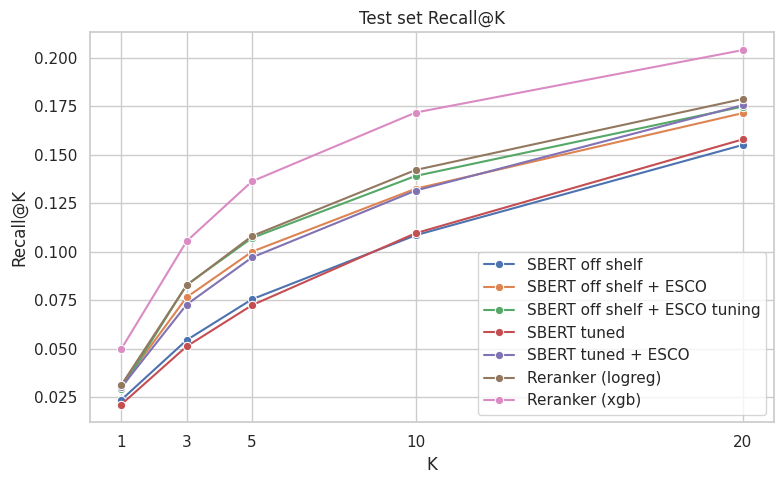

In [ ]:
systems = [
    "SBERT off shelf",
    "SBERT off shelf + ESCO",
    "SBERT off shelf + ESCO tuning",
    "SBERT tuned",
    "SBERT tuned + ESCO",
    "Reranker (logreg)",
    "Reranker (xgb)",
]

K_list = [1, 3, 5, 10, 20]

# Build plotting dataframe
plot_rows = []
for sys in systems:
    for K in K_list:
        key = f"recall@{K}"
        if key in test_table.index:
            plot_rows.append({"System": sys, "K": K, "Recall": float(test_table.loc[key, sys])})

plot_df = pd.DataFrame(plot_rows)

# Plot
sns.set(style="whitegrid")
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=plot_df,
    x="K",
    y="Recall",
    hue="System",
    marker="o"
)

plt.xticks(K_list)
plt.xlabel("K")
plt.ylabel("Recall@K")
plt.title("Test set Recall@K")
plt.legend(title="", loc="lower right")
plt.tight_layout()
plt.show()